<div style="padding:22px 26px;border-radius:8px;background:rgba(74,58,167,0.08);border-left:6px solid #4A3AA7"><div style="font-size:0.8em;letter-spacing:0.12em;text-transform:uppercase;color:#8A94A3">CHURN-VALUE · pipeline stage 03</div><div style="font-size:2em;font-weight:700;margin:4px 0 6px;color:#4A3AA7">Exploratory data analysis</div><div style="font-size:1.05em;opacity:0.85">How these customers buy — the behaviour a churn label will be built on.</div></div>

Stage 02 asked *which rows describe a customer buying a product?*; this stage asks *how do
those customers buy?* Three properties matter for everything downstream: **when** the business
sells (seasonality), **how regularly** each customer returns (cadence), and **how unequal**
customers are in value (concentration). The first will threaten calibration, the second defines
the label, the third decides where retention money should go.

**Pipeline rule.** Descriptive only, on the clean transactions. Customer-level quantities come
from `churnvalue.features` — the same functions the model uses — computed at the last day of
data, so no label and no cutoff logic is involved yet (that is stage 04).

| | |
|---|---|
| **Input** | `data/interim/transactions.parquet` (from `churnvalue build-snapshots`, rules of stage 02) |
| **Outputs** | `reports/results/03_summary.json` · `reports/figures/03_*.png` |
| **Parameters** | `configs/default.yaml` → `snapshots.horizon_days`, `snapshots.cadence_floor_days` |
| **Shared code** | `churnvalue.features` (purchase days, customer features) · `churnvalue.viz.style` |

<div style="display:flex;gap:8px;flex-wrap:wrap;margin:8px 0 4px;font-family:monospace;font-size:0.85em"><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">E1 seasonality</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">E2 frequency</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">E3 cadence</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">E4 concentration</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">E5 returns</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">E6 geography</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">E7 recency</span><span style="background:rgba(74,58,167,0.08);color:#4A3AA7;border:1px solid rgba(74,58,167,0.35);border-radius:4px;padding:3px 10px">✓ hand-off</span></div>

**Colour convention** (fixed for the whole project): single-series magnitude is slate; grey is
context; a darker slate marks the subgroup a chart is about. Red is reserved for churners and
appears from stage 04 on.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from churnvalue.config import load_config, project_root
from churnvalue.features import add_derived_features, compute_base_features, purchase_days
from churnvalue.reporting import StageSummary
from churnvalue.viz import style
from churnvalue.viz.style import GRID, INK, MUTED, NEUTRAL, RETAINED, SEQUENTIAL

os.chdir(project_root())
CFG = load_config()
STAGE, FIGURES, RESULTS = "03", Path("reports/figures"), Path("reports/results")
S = StageSummary(STAGE)
style.apply_style()


def save(fig, name):
    return style.save_fig(fig, FIGURES, STAGE, name)


tx = pd.read_parquet(CFG.data.interim_dir / "transactions.parquet")
END = tx["date"].max()
H = CFG.snapshots.horizon_days
days = purchase_days(tx)  # one row per customer and purchase day, returns excluded
customers = add_derived_features(
    compute_base_features(tx, END, H), H, CFG.snapshots.cadence_floor_days
)
S["customers"] = len(customers)
S["purchase_days"] = len(days)
S["data_end"] = END

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">E1 · Seasonality</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">the whole business breathes once a year</span></div>

Monthly revenue and monthly active customers, on separate panels with a shared time axis — two
measures of different scale never share one axis. The daily calendar below shows the same
rhythm at a finer grain, and one structural fact: this business almost never trades on a
Saturday (a single Saturday in two years).

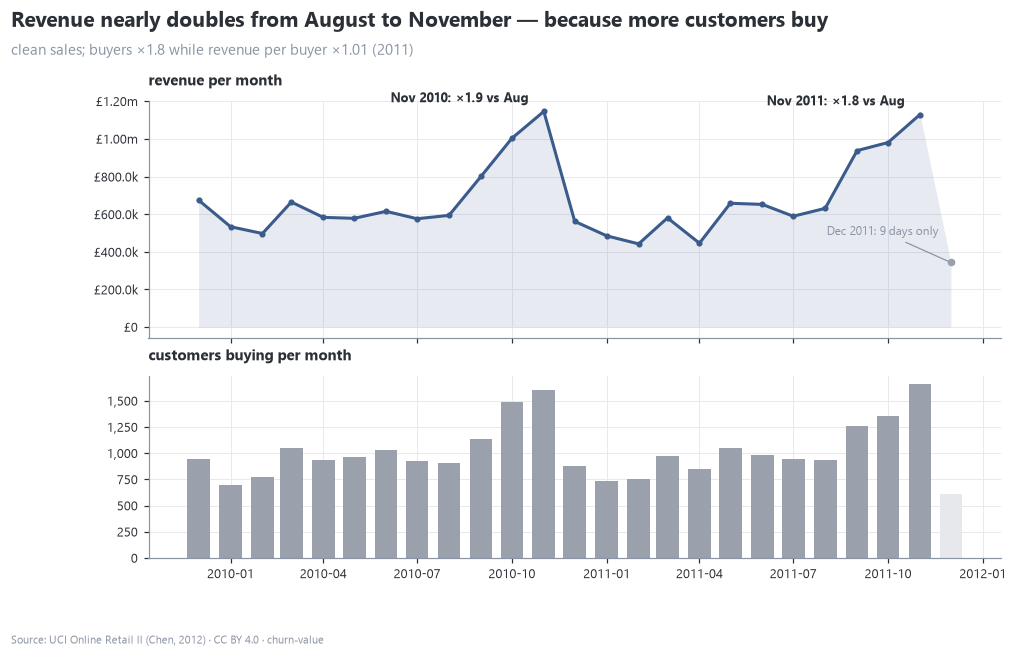

In [2]:
sales = tx.loc[~tx["is_return"]]
month = sales["date"].dt.to_period("M").dt.to_timestamp()
revenue_m = sales.groupby(month)["revenue"].sum()
active_m = sales.groupby(month)["customer_id"].nunique()
complete = revenue_m.index < pd.Timestamp("2011-12-01")  # December 2011 has only 9 days
for year in (2010, 2011):
    aug, nov = pd.Timestamp(f"{year}-08-01"), pd.Timestamp(f"{year}-11-01")
    S[f"nov_over_aug_revenue_{year}"] = revenue_m[nov] / revenue_m[aug]
    S[f"nov_over_aug_customers_{year}"] = active_m[nov] / active_m[aug]
    S[f"nov_over_aug_revenue_per_customer_{year}"] = (revenue_m[nov] / active_m[nov]) / (
        revenue_m[aug] / active_m[aug]
    )
S["revenue_peak_month"] = revenue_m[complete].idxmax()
S["revenue_growth_2011_vs_2010"] = (
    revenue_m["2011-01-01":"2011-11-01"].sum() / revenue_m["2010-01-01":"2010-11-01"].sum() - 1
)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 5.4), sharex=True, gridspec_kw={"height_ratios": [1.3, 1], "hspace": 0.18}
)
ax1.fill_between(revenue_m.index, revenue_m, color=NEUTRAL, alpha=0.12, lw=0)
ax1.plot(revenue_m.index[complete], revenue_m[complete], color=NEUTRAL, marker="o", markersize=3)
ax1.plot(revenue_m.index[~complete], revenue_m[~complete], "o", color=RETAINED, markersize=4)
ax1.annotate(
    "Dec 2011: 9 days only",
    xy=(revenue_m.index[-1], revenue_m.iloc[-1]),
    xytext=(-8, 18),
    textcoords="offset points",
    ha="right",
    fontsize=8,
    color=MUTED,
    arrowprops={"arrowstyle": "-", "color": MUTED, "lw": 0.8},
)
for year in (2010, 2011):
    nov = pd.Timestamp(f"{year}-11-01")
    ax1.annotate(
        f"Nov {year}: ×{S[f'nov_over_aug_revenue_{year}']:.1f} vs Aug",
        xy=(nov, revenue_m[nov]),
        xytext=(-10, 6),
        textcoords="offset points",
        ha="right",
        fontsize=8.5,
        color=INK,
        fontweight="bold",
    )
ax1.yaxis.set_major_formatter(lambda v, _: style.gbp(v))
ax1.set_title("revenue per month", fontsize=10)
ax2.bar(active_m.index, active_m, width=22, color=RETAINED)
ax2.bar(active_m.index[~complete], active_m[~complete], width=22, color=GRID)
ax2.set_title("customers buying per month", fontsize=10)
ax2.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
style.headline(
    fig,
    "Revenue nearly doubles from August to November — because more customers buy",
    f"clean sales; buyers ×{S['nov_over_aug_customers_2011']:.1f} while revenue per buyer "
    f"×{S['nov_over_aug_revenue_per_customer_2011']:.2f} (2011)",
)
style.add_source(fig)
save(fig, "seasonality")
plt.show()

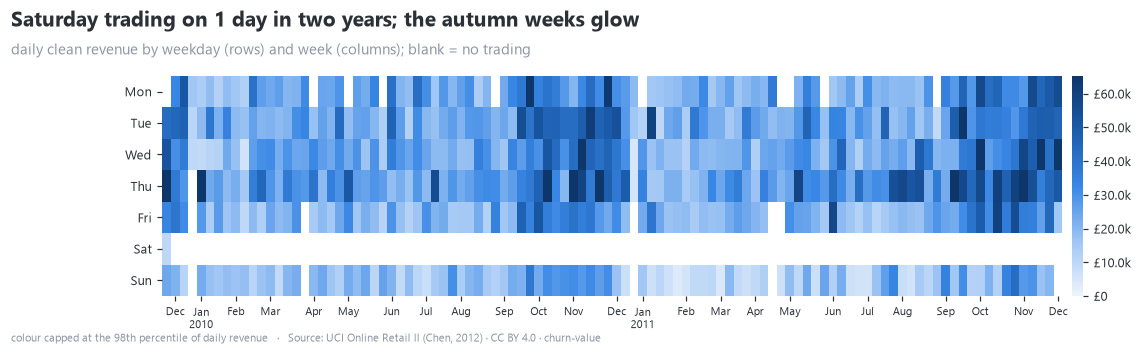

In [3]:
daily = sales.groupby("date")["revenue"].sum()
calendar = pd.DataFrame({"revenue": daily})
calendar["weekday"] = calendar.index.dayofweek
calendar["week"] = calendar.index.to_period("W-SUN").start_time
grid = calendar.pivot_table(index="weekday", columns="week", values="revenue").reindex(range(7))
S["trading_weekdays"] = sorted(calendar["weekday"].unique().tolist())
S["saturday_trading_days"] = int((calendar["weekday"] == 5).sum())

fig, ax = plt.subplots(figsize=(11, 2.6))
values = grid.to_numpy()
mesh = ax.imshow(
    values,
    aspect="auto",
    cmap=SEQUENTIAL,
    interpolation="nearest",
    vmin=0,
    vmax=np.nanpercentile(values, 98),
)
ax.set_yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
weeks = list(grid.columns)
starts = [i for i, w in enumerate(weeks) if i == 0 or w.month != weeks[i - 1].month]
if len(starts) > 1 and starts[1] - starts[0] < 3:  # partial first month: no crowded label
    starts = starts[1:]
ax.set_xticks(
    starts, [weeks[i].strftime("%b\n%Y" if weeks[i].month == 1 or i == 0 else "%b") for i in starts]
)
ax.tick_params(axis="x", labelsize=7.5)
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(mesh, ax=ax, pad=0.01, fraction=0.03)
cbar.ax.yaxis.set_major_formatter(lambda v, _: style.gbp(v))
cbar.outline.set_visible(False)
style.headline(
    fig,
    f"Saturday trading on {S['saturday_trading_days']} day in two years; the autumn weeks glow",
    "daily clean revenue by weekday (rows) and week (columns); blank = no trading",
)
style.add_source(fig, "colour capped at the 98th percentile of daily revenue")
save(fig, "calendar")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">E2 · Frequency</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">more than a quarter never come back</span></div>

A *purchase* is a distinct day with at least one sale (stage 02). The distribution is
heavy-tailed, so the bins are logarithmic. One-time buyers matter twice: they have no cadence
(so they cannot be *overdue*), and a large share of them is the reason a churn label has to be
restricted to repeat customers.

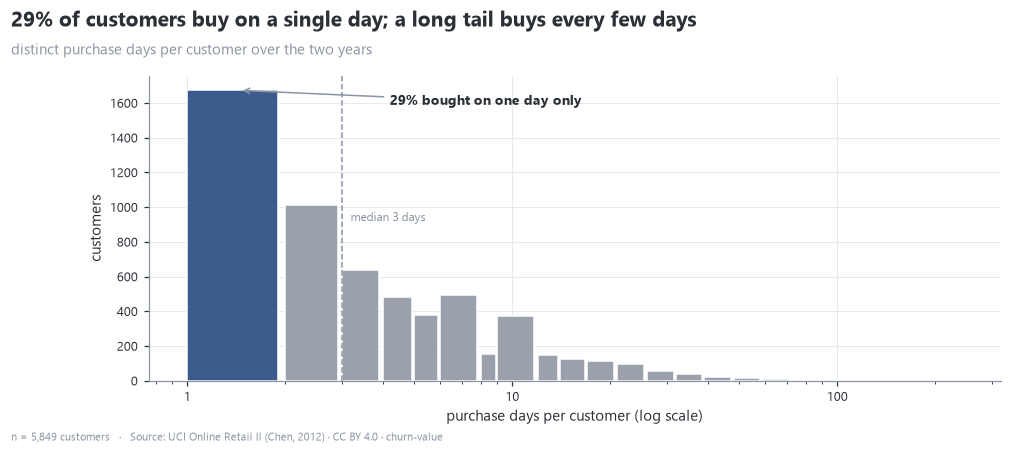

In [4]:
n = customers["n_purchase_days"]
S["one_time_share"] = (n == 1).mean()
S["repeat_customers"] = int((n >= 2).sum())
S["median_purchase_days"] = n.median()
S["p90_purchase_days"] = n.quantile(0.9)

bins = np.unique(np.round(np.geomspace(1, n.max() + 1, 28)).astype(int))
counts, edges = np.histogram(n, bins=bins)
fig, ax = plt.subplots(figsize=(10, 3.6))
colors = [NEUTRAL if lo == 1 else RETAINED for lo in edges[:-1]]
ax.bar(
    edges[:-1], counts, width=np.diff(edges) * 0.9, align="edge", color=colors, edgecolor="white"
)
ax.set_xscale("log")
ax.set_xlabel("purchase days per customer (log scale)")
ax.set_ylabel("customers")
ax.annotate(
    f"{S['one_time_share']:.0%} bought on one day only",
    xy=(1.45, counts[0]),
    xytext=(4.2, counts[0] * 0.95),
    fontsize=9,
    color=INK,
    fontweight="bold",
    arrowprops={"arrowstyle": "->", "color": MUTED, "lw": 1},
)
ax.axvline(S["median_purchase_days"], color=MUTED, lw=1, ls="--")
ax.text(
    S["median_purchase_days"] * 1.06,
    counts.max() * 0.55,
    f"median {S['median_purchase_days']:.0f} days",
    fontsize=8,
    color=MUTED,
)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
style.headline(
    fig,
    f"{S['one_time_share']:.0%} of customers buy on a single day; a long tail buys every few days",
    "distinct purchase days per customer over the two years",
)
style.add_source(fig, f"n = {S['customers']:,} customers")
save(fig, "frequency")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">E3 · Cadence</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">frequent buyers are also regular buyers</span></div>

For every repeat customer, the gaps between consecutive purchase days. Grouped by how often the
customer buys, the distributions do not just shift — they **narrow**: the more a customer buys,
the more predictable the next purchase. That regularity is what makes "overdue relative to your
own rhythm" a meaningful signal, and it is the idea behind the eligibility window of stage 04.

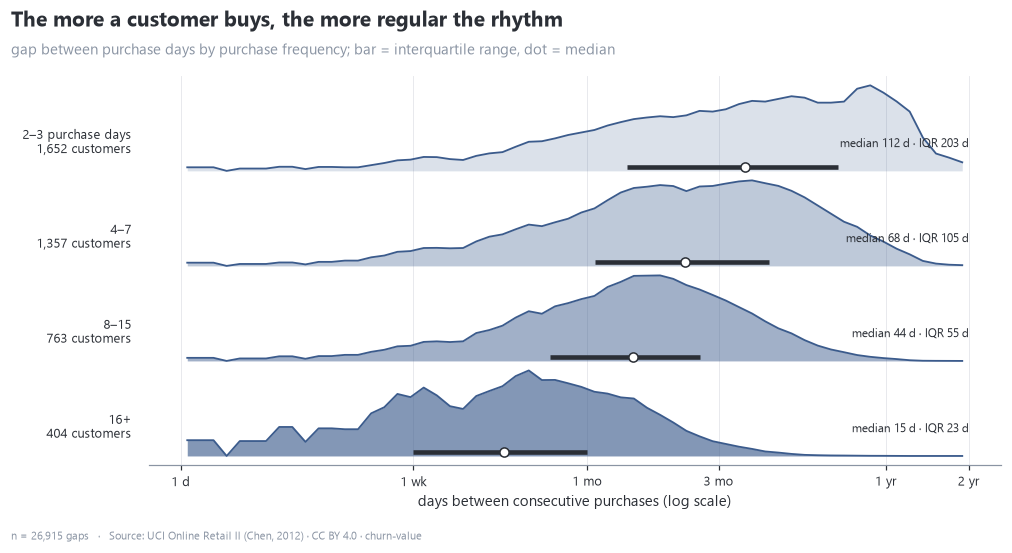

In [5]:
ordered = days.sort_values(["customer_id", "date"])
ordered["gap"] = ordered.groupby("customer_id")["date"].diff().dt.days
gaps = ordered.dropna(subset=["gap"]).merge(
    customers["n_purchase_days"], left_on="customer_id", right_index=True
)
tiers = pd.cut(
    gaps["n_purchase_days"],
    [1, 3, 7, 15, np.inf],
    labels=["2–3 purchase days", "4–7", "8–15", "16+"],
)
gaps["tier"] = tiers
tier_stats = gaps.groupby("tier", observed=True)["gap"].describe(percentiles=[0.25, 0.5, 0.75])
tier_customers = gaps.groupby("tier", observed=True)["customer_id"].nunique()
S["gap_median_by_tier"] = tier_stats["50%"].to_dict()
S["gap_iqr_by_tier"] = (tier_stats["75%"] - tier_stats["25%"]).to_dict()

log_grid = np.linspace(0, np.log10(730), 300)
fig, ax = plt.subplots(figsize=(10, 4.6))
labels = list(tier_stats.index)
for i, tier in enumerate(labels):
    values = np.log10(gaps.loc[gaps["tier"] == tier, "gap"].clip(lower=1))
    density, edges = np.histogram(values, bins=60, range=(0, np.log10(730)), density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    smooth = np.convolve(density, np.ones(5) / 5, mode="same")
    height = smooth / smooth.max() * 0.9
    base = len(labels) - 1 - i
    ax.fill_between(centers, base, base + height, color=NEUTRAL, alpha=0.18 + 0.15 * i, lw=0)
    ax.plot(centers, base + height, color=NEUTRAL, lw=1.2)
    q1, med, q3 = tier_stats.loc[tier, ["25%", "50%", "75%"]]
    ax.hlines(base + 0.04, np.log10(q1), np.log10(q3), color=INK, lw=3)
    ax.plot(np.log10(med), base + 0.04, "o", color="white", markeredgecolor=INK, markersize=6)
    ax.text(
        np.log10(730),
        base + 0.25,
        f"median {med:.0f} d · IQR {q3 - q1:.0f} d",
        ha="right",
        fontsize=8,
        color=INK,
    )
    ax.text(
        -0.02,
        base + 0.3,
        f"{tier}\n{tier_customers[tier]:,} customers",
        ha="right",
        va="center",
        fontsize=8.5,
        color=INK,
        transform=ax.get_yaxis_transform(),
    )
ticks = [1, 7, 30, 90, 365, 730]
ax.set_xticks(np.log10(ticks), ["1 d", "1 wk", "1 mo", "3 mo", "1 yr", "2 yr"])
ax.set_yticks([])
ax.set_ylim(-0.1, len(labels))
ax.spines["left"].set_visible(False)
ax.set_xlabel("days between consecutive purchases (log scale)")
style.headline(
    fig,
    "The more a customer buys, the more regular the rhythm",
    "gap between purchase days by purchase frequency; bar = interquartile range, dot = median",
)
style.add_source(fig, f"n = {len(gaps):,} gaps")
save(fig, "cadence")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">E4 · Concentration</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">a few accounts carry the business</span></div>

The Lorenz curve orders customers from smallest to largest spend and plots the cumulative
share of revenue. The further it bows from the diagonal, the more unequal the value — and the
more a retention budget should be allocated by value, not headcount. That is why the economics
weigh each customer by their own value at risk *V* instead of treating churners as equal.

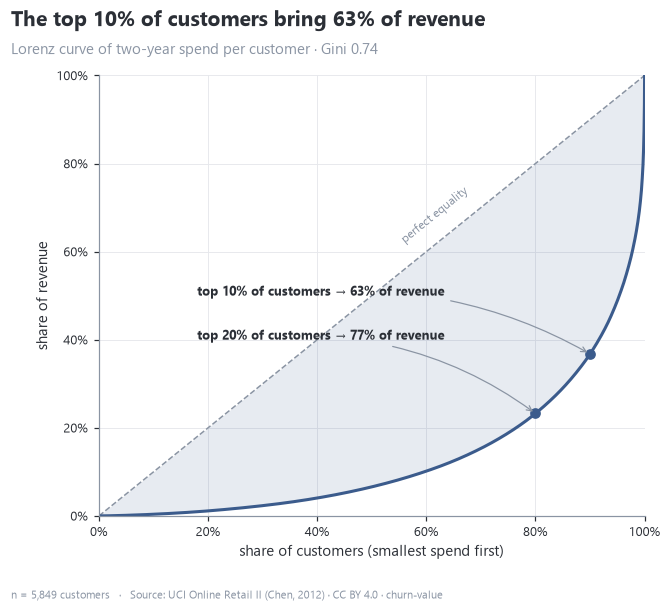

In [6]:
spend = customers["total_spend"].clip(lower=0).sort_values()
cum_customers = np.arange(1, len(spend) + 1) / len(spend)
cum_revenue = spend.cumsum() / spend.sum()
gini = 1 - 2 * np.trapezoid(np.r_[0, cum_revenue.to_numpy()], np.r_[0, cum_customers])
top = {share: 1 - np.interp(1 - share, cum_customers, cum_revenue) for share in (0.01, 0.1, 0.2)}
S["gini_spend"] = gini
S["revenue_share_of_top"] = {f"{int(k * 100)}%": v for k, v in top.items()}

fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax.fill_between(cum_customers, cum_revenue, cum_customers, color=NEUTRAL, alpha=0.12, lw=0)
ax.plot(cum_customers, cum_revenue, color=NEUTRAL)
for share, text_xy in [(0.1, (0.18, 0.50)), (0.2, (0.18, 0.40))]:
    x = 1 - share
    y = 1 - top[share]
    ax.plot(x, y, "o", color=NEUTRAL, markersize=6)
    ax.annotate(
        f"top {share:.0%} of customers → {top[share]:.0%} of revenue",
        xy=(x, y),
        xytext=text_xy,
        fontsize=8.5,
        color=INK,
        fontweight="bold",
        arrowprops={
            "arrowstyle": "->",
            "color": MUTED,
            "lw": 0.8,
            "connectionstyle": "arc3,rad=-0.15",
        },
    )
ax.text(0.55, 0.62, "perfect equality", rotation=39, fontsize=8, color=MUTED)
ax.set_xlabel("share of customers (smallest spend first)")
ax.set_ylabel("share of revenue")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
style.headline(
    fig,
    f"The top 10% of customers bring {top[0.1]:.0%} of revenue",
    f"Lorenz curve of two-year spend per customer · Gini {gini:.2f}",
)
style.add_source(fig, f"n = {S['customers']:,} customers")
save(fig, "concentration")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">E5 · Returns</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">who sends goods back</span></div>

Stage 02 kept genuine returns. At customer level the question is whether returning goods marks
a disengaging customer or simply a larger one. The dot plot compares, by purchase frequency, the
share of customers with at least one return and the median return rate among them.

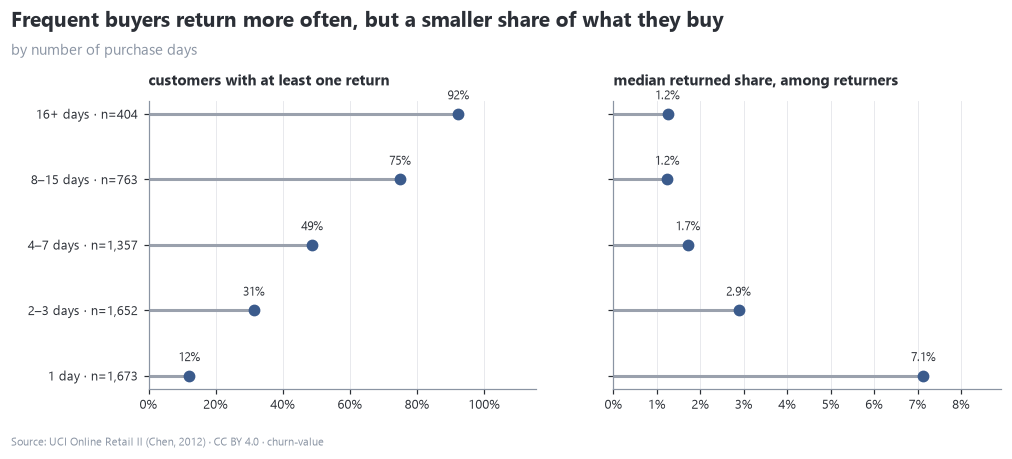

In [7]:
customers["tier"] = pd.cut(
    customers["n_purchase_days"],
    [0, 1, 3, 7, 15, np.inf],
    labels=["1", "2–3", "4–7", "8–15", "16+"],
)
by_tier = customers.groupby("tier", observed=True).agg(
    customers=("return_rate", "size"),
    any_return=("return_rate", lambda r: (r > 0).mean()),
    median_rate=("return_rate", lambda r: r[r > 0].median()),
)
S["returns_by_tier"] = by_tier.to_dict(orient="index")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
y = np.arange(len(by_tier))
for ax, column, title, fmt in [
    (ax1, "any_return", "customers with at least one return", "{:.0%}"),
    (ax2, "median_rate", "median returned share, among returners", "{:.1%}"),
]:
    ax.hlines(y, 0, by_tier[column], color=RETAINED, lw=2)
    ax.scatter(by_tier[column], y, color=NEUTRAL, s=45, zorder=3)
    for yi, v in zip(y, by_tier[column], strict=True):
        ax.text(v, yi + 0.22, fmt.format(v), ha="center", fontsize=8, color=INK)
    ax.set_title(title, fontsize=10)
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, by_tier[column].max() * 1.25)
tick_labels = [
    f"{t} {'day' if t == '1' else 'days'} · n={c:,}"
    for t, c in zip(by_tier.index, by_tier["customers"], strict=True)
]
ax1.set_yticks(y, tick_labels)
style.headline(
    fig,
    "Frequent buyers return more often, but a smaller share of what they buy",
    "by number of purchase days",
)
style.add_source(fig)
save(fig, "returns_by_frequency")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">E6 · Geography</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">a British business with a European account base</span></div>

Customers and revenue per customer by country (top 10, the rest grouped). Sorted, direct-labelled
bars instead of a map: with most customers in one country, a choropleth would only restate that.

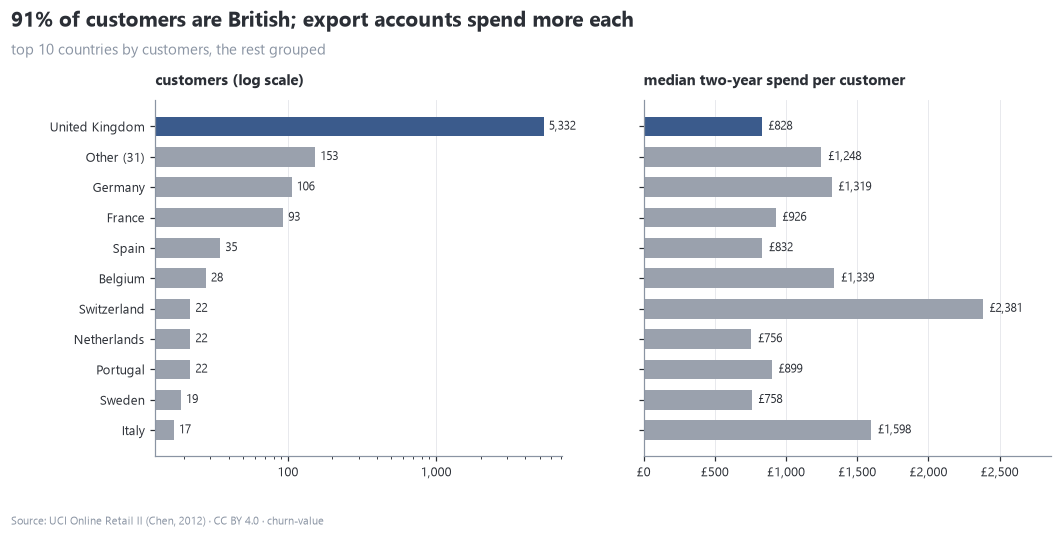

In [8]:
country = customers.join(
    tx.loc[~tx["is_return"]].groupby("customer_id")["country"].agg(lambda s: s.mode().iat[0])
)
top10 = country["country"].value_counts().head(10).index
country["group"] = country["country"].where(country["country"].isin(top10), "Other (31)")
n_other = country.loc[~country["country"].isin(top10), "country"].nunique()
country["group"] = country["group"].replace("Other (31)", f"Other ({n_other})")
geo = country.groupby("group").agg(
    customers=("total_spend", "size"), spend=("total_spend", "median")
)
geo = geo.sort_values("customers")
S["uk_customer_share"] = (country["country"] == "United Kingdom").mean()
S["median_spend_uk"] = geo.loc["United Kingdom", "spend"]
non_uk = country["country"] != "United Kingdom"
S["median_spend_non_uk"] = country.loc[non_uk, "total_spend"].median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
colors = [NEUTRAL if g == "United Kingdom" else RETAINED for g in geo.index]
ax1.barh(geo.index, geo["customers"], color=colors, height=0.65)
ax1.set_xscale("log")
for g, v in geo["customers"].items():
    ax1.text(v * 1.08, g, f"{v:,}", va="center", fontsize=8, color=INK)
ax1.set_title("customers (log scale)", fontsize=10)
ax1.xaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax2.barh(geo.index, geo["spend"], color=colors, height=0.65)
for g, v in geo["spend"].items():
    ax2.text(v + geo["spend"].max() * 0.02, g, style.gbp(v), va="center", fontsize=8, color=INK)
ax2.set_title("median two-year spend per customer", fontsize=10)
ax2.xaxis.set_major_formatter(lambda v, _: style.gbp(v))
ax2.set_xlim(0, geo["spend"].max() * 1.2)
for ax in (ax1, ax2):
    ax.grid(axis="y", visible=False)
style.headline(
    fig,
    f"{S['uk_customer_share']:.0%} of customers are British; export accounts spend more each",
    "top 10 countries by customers, the rest grouped",
)
style.add_source(fig)
save(fig, "geography")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">E7 · Recency</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">the churn question, seen at the end of the data</span></div>

For every repeat customer, the days since their last purchase against their usual gap (cadence).
A customer on the diagonal is exactly one cycle late; above the "2 × cadence" line, they have
missed two expected purchases. This is the picture stage 04 turns into a label: silence only
means something *relative to a customer's own rhythm*.

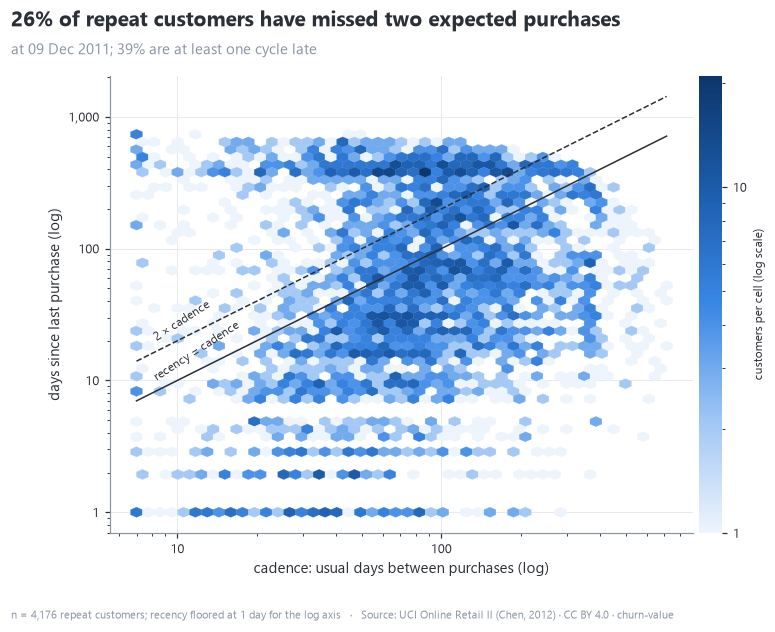

In [9]:
rep = customers[customers["n_purchase_days"] >= 2]
overdue_1 = (rep["recency_days"] > rep["cadence_days"]).mean()
overdue_2 = (rep["recency_days"] > 2 * rep["cadence_days"]).mean()
S["repeat_overdue_1x"] = overdue_1
S["repeat_overdue_2x"] = overdue_2

fig, ax = plt.subplots(figsize=(7.2, 5.4))
recency_plot = rep["recency_days"].clip(lower=1)  # log axis; bought-on-the-last-day -> 1 day
hb = ax.hexbin(
    rep["cadence_days"],
    recency_plot,
    gridsize=45,
    xscale="log",
    yscale="log",
    cmap=SEQUENTIAL,
    mincnt=1,
    bins="log",
    linewidths=0.2,
    edgecolors="face",
)
line = np.geomspace(rep["cadence_days"].min(), rep["cadence_days"].max(), 50)
ax.plot(line, line, color=INK, lw=1)
ax.plot(line, 2 * line, color=INK, lw=1, ls="--")
ax.text(8, 8 * 1.25, "recency = cadence", rotation=33, fontsize=8, color=INK)
ax.text(8, 16 * 1.25, "2 × cadence", rotation=33, fontsize=8, color=INK)
ax.set_xlabel("cadence: usual days between purchases (log)")
ax.set_ylabel("days since last purchase (log)")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
cbar = fig.colorbar(hb, ax=ax, pad=0.01, fraction=0.04)
cbar.set_label("customers per cell (log scale)", fontsize=8)
cbar.ax.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
cbar.ax.yaxis.set_minor_formatter(lambda v, _: "")
cbar.outline.set_visible(False)
style.headline(
    fig,
    f"{overdue_2:.0%} of repeat customers have missed two expected purchases",
    f"at {END:%d %b %Y}; {overdue_1:.0%} are at least one cycle late",
)
style.add_source(
    fig, f"n = {len(rep):,} repeat customers; recency floored at 1 day for the log axis"
)
save(fig, "recency_vs_cadence")
plt.show()

<div style="margin-top:1.6em;padding:10px 16px;border-left:6px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0;display:flex;align-items:center;justify-content:space-between;gap:12px"><span style="font-size:1.35em;font-weight:600;color:#4A3AA7">✓ · Summary and hand-off</span><span style="font-family:monospace;font-size:0.8em;color:#8A94A3;background:rgba(128,128,128,0.08);border:1px solid rgba(128,128,128,0.3);border-radius:4px;padding:2px 8px;white-space:nowrap">03 → 04, 05</span></div>

**Produced** — `reports/results/03_summary.json` and the figures `03_seasonality`,
`03_calendar`, `03_frequency`, `03_cadence`, `03_concentration`, `03_returns_by_frequency`,
`03_geography`, `03_recency_vs_cadence`.

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #B7791F;background:rgba(183,121,31,0.12);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#B7791F">Key finding</span><ul style="margin:6px 0 0 18px;padding:0"><li>Strong, repeatable seasonality: revenue nearly doubles from August to November in both years, through more buyers (×1.8) rather than bigger baskets (×1.0–1.1).</li><li>Purchase rhythm is personal and gets more regular with frequency — "late" only means something relative to a customer's own cadence.</li><li>Value is concentrated: a small share of accounts carries most revenue, so retention must be weighted by value.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #4A3AA7;background:rgba(74,58,167,0.08);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#4A3AA7">Decision taken here</span><ul style="margin:6px 0 0 18px;padding:0"><li>None on the data. This stage is descriptive.</li></ul></div>

<div style="margin:10px 0;padding:10px 14px;border-left:4px solid #3B5B8C;background:rgba(59,91,140,0.10);border-radius:0 6px 6px 0"><span style="font-size:0.75em;font-weight:700;letter-spacing:0.06em;text-transform:uppercase;color:#3B5B8C">Left for a later stage</span><ul style="margin:6px 0 0 18px;padding:0"><li><b>04_problem_framing</b> — cadence becomes the eligibility window and one-time buyers are excluded; the seasonality becomes the central risk to calibration.</li><li><b>05_feature_engineering</b> — cadence, recency relative to cadence and a same-season-last-year flag become features.</li><li><b>06_baselines</b> — concentration motivates value-weighted economics (<i>V</i>, CRC, CAC).</li></ul></div>

In [10]:
S.write(RESULTS)

WindowsPath('reports/results/03_summary.json')